In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
fdir = "/home/cmp/Documents/Github/QPI-Scattering/CAnalytics/output/sep20.000000a/condensed-ldos.tsv"

In [134]:
head = pd.read_csv(fdir, sep="\t", nrows=1)

nx, ny, dx, dy, sx, sy, sep = head.iloc[0].tolist()

In [135]:
df = pd.read_csv(fdir, sep="\t", header=None, dtype=np.double, skiprows=3)
Z = df.to_numpy()

In [136]:
a = 0.24595 #nm
acc = 0.142
h = 2*acc * np.tan(np.pi/3)
sep = int(sep)


xlin = np.linspace(-sx, sx, int(nx))
ylin = np.linspace(-sy, sy, int(ny))
X, Y = np.meshgrid(xlin, ylin)

In [137]:
def makeLog(Z):
    return np.log(Z + np.abs(np.min(Z)) + 1)

In [138]:
makeLog(1e-7)

np.float64(1.999999798947315e-07)

In [139]:
np.min(Z)

np.float64(-16.7708)

-0.0866537


(-5.01, 5.01)

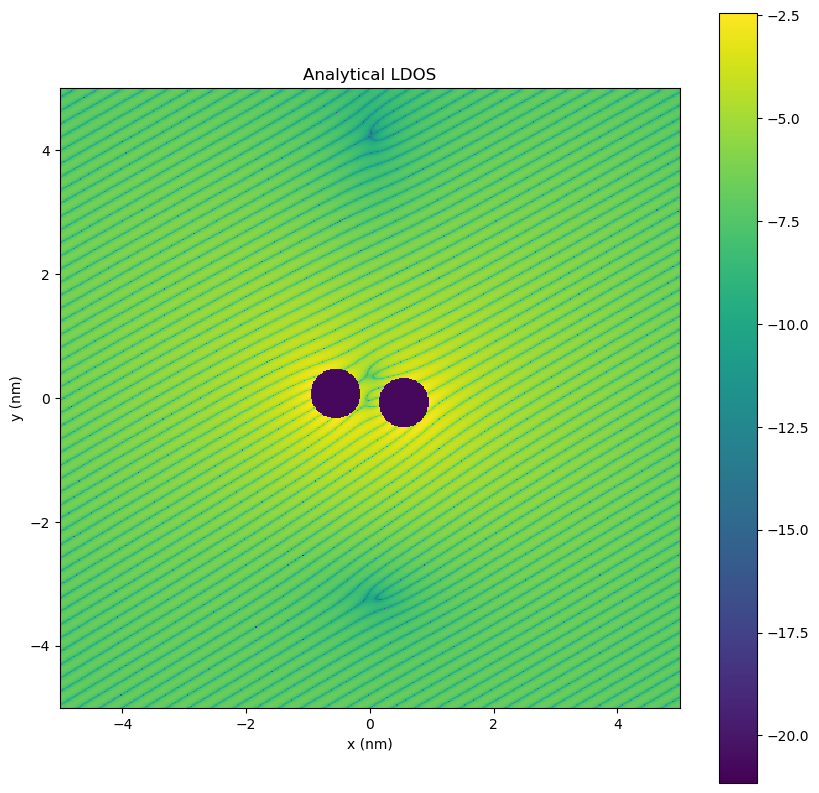

In [140]:
#double R1x = -0.55;
#double R1y = 0.071;
#double R2x = 0.55;
#double R2y = -0.071;

xa = 1.17
ya = 0.32

xa = 1.23
ya = 0.39

#xa = sep * h
#ya = 0

# We create a mask because our functions blow up at r -> zero
maskr = 0.4
mask1 = ((X+0.55) ** 2 + (Y-0.071) ** 2) <= maskr**2
mask2 = ((X-0.55) ** 2 + (Y+0.071) ** 2) <= maskr**2

mask = mask1 | mask2

fig, ax = plt.subplots(figsize=(10, 10))

Z[mask]=0

ZR = Z * (((X+xa) ** 2 + (Y+ya) ** 2)+ ((X-xa) ** 2 + (Y-ya) ** 2))

print(np.min(Z))

#pc = ax.pcolormesh(xlin, ylin, ZR2, cmap="winter", vmax=15, vmin=-15)
#pc = ax.pcolormesh(xlin, ylin, Z_masked, cmap="winter", vmax=1.5)
pc = ax.pcolormesh(xlin, ylin, np.log(np.abs(Z + 1e-9)))
fig.colorbar(pc)

ax.set_title("Analytical LDOS")

ax.set_aspect('equal')
ax.set_xlabel('x (nm)')
ax.set_ylabel('y (nm)')

ax.set_xlim()

In [141]:
# Fourier Transform
Z_fft = np.fft.fft2(Z_masked)
Z_fft_shifted = np.fft.fftshift(Z_fft)
magnitude_spectrum = np.abs(Z_fft_shifted)

NameError: name 'Z_masked' is not defined

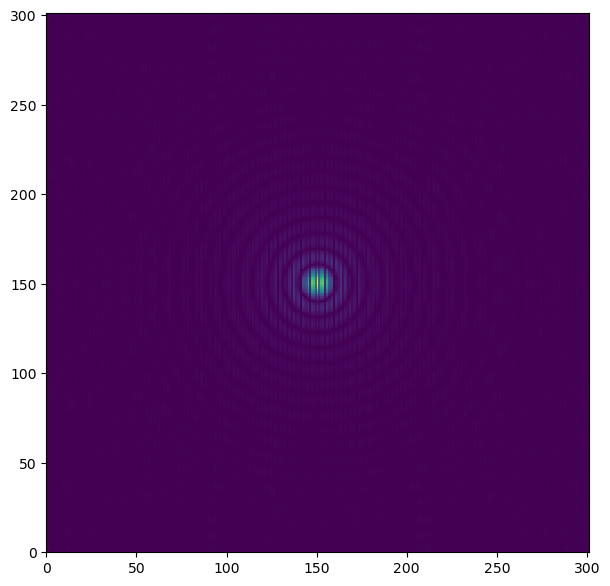

In [ ]:
fig1, ax1 = plt.subplots(figsize=(7,7))

ax1.pcolormesh((magnitude_spectrum))